In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [2]:
dataset = pd.read_excel("soil data.xlsx", header = 1)
dataset.head()

,No.,Soil 1,Soil 2,Soil 3,Soil4,Soil5,Forest,Urban,Range,Agriculture,Barren,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,>40,Runoff,Sediment Yield
0,1,97.00000,0.00000,0.0,0.0,3.00000,0.000000,66.80853,27.821520,1.428380,2.614343,99.80000,0.200000,0.000000,0.0,0.0,16.049500,0.18
1,2,99.50000,0.00000,0.0,0.0,0.50000,0.000000,85.96467,9.652197,0.396351,3.287800,100.00000,0.000000,0.000000,0.0,0.0,8.113267,0.16
2,3,49.00000,0.00000,0.0,0.0,51.00000,0.035806,55.00465,36.593760,3.252676,3.898018,99.05000,0.050000,0.000000,0.0,0.0,12.792220,0.12
3,4,40.86021,0.00000,0.0,0.0,59.13979,0.000000,68.42843,15.819910,3.054291,5.695412,97.56486,2.330938,0.104207,0.0,0.0,46.088960,2.47
4,5,21.55689,64.67066,0.0,0.0,13.77246,0.000000,58.31792,21.479580,3.840518,9.698103,98.38277,1.611267,0.005968,0.0,0.0,48.155760,0.90


In [3]:
dataset = dataset.drop(columns = ['No.'])
dataset = dataset.rename(columns ={'Unnamed: 11' : 'Slope 1-10','Unnamed: 12' : 'Slope 1-10','Unnamed: 13' : 'Slope 10-20','Unnamed: 14' : 'Slope 30-40','>40' : 'Slope 40+',}).copy()
dataset.head()

,Soil 1,Soil 2,Soil 3,Soil4,Soil5,Forest,Urban,Range,Agriculture,Barren,Slope 1-10,Slope 1-10,Slope 10-20,Slope 30-40,Slope 40+,Runoff,Sediment Yield
0,97.00000,0.00000,0.0,0.0,3.00000,0.000000,66.80853,27.821520,1.428380,2.614343,99.80000,0.200000,0.000000,0.0,0.0,16.049500,0.18
1,99.50000,0.00000,0.0,0.0,0.50000,0.000000,85.96467,9.652197,0.396351,3.287800,100.00000,0.000000,0.000000,0.0,0.0,8.113267,0.16
2,49.00000,0.00000,0.0,0.0,51.00000,0.035806,55.00465,36.593760,3.252676,3.898018,99.05000,0.050000,0.000000,0.0,0.0,12.792220,0.12
3,40.86021,0.00000,0.0,0.0,59.13979,0.000000,68.42843,15.819910,3.054291,5.695412,97.56486,2.330938,0.104207,0.0,0.0,46.088960,2.47
4,21.55689,64.67066,0.0,0.0,13.77246,0.000000,58.31792,21.479580,3.840518,9.698103,98.38277,1.611267,0.005968,0.0,0.0,48.155760,0.90


<Axes: >

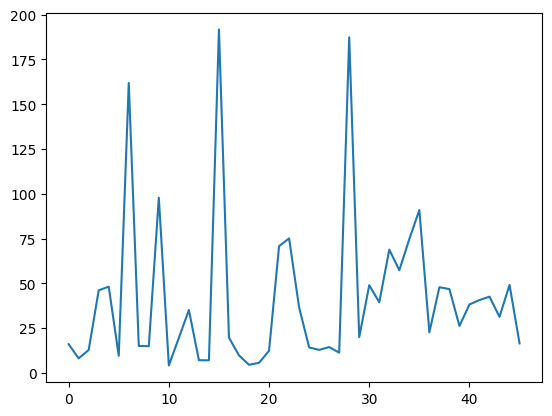

In [4]:
dataset['Runoff'].plot()


<Axes: >

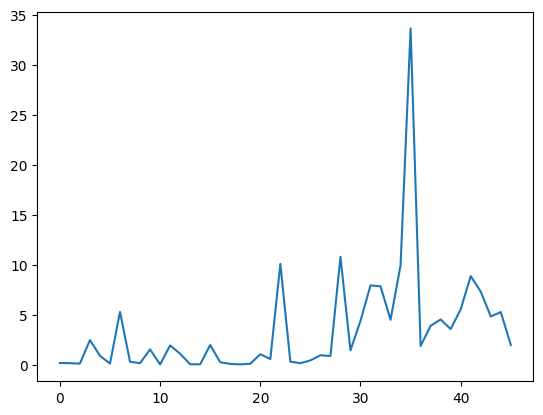

In [5]:
dataset['Sediment Yield'].plot()

In [6]:
dataset = dataset[dataset['Runoff'] <= 100]
dataset

,Soil 1,Soil 2,Soil 3,Soil4,Soil5,Forest,Urban,Range,Agriculture,Barren,Slope 1-10,Slope 1-10,Slope 10-20,Slope 30-40,Slope 40+,Runoff,Sediment Yield
0,97.000000,0.00000,0.000000,0.00000,3.00000,0.000000,66.808530,27.821520,1.428380,2.614343,99.80000,0.200000,0.000000,0.000000,0.000000,16.049500,0.18
1,99.500000,0.00000,0.000000,0.00000,0.50000,0.000000,85.964670,9.652197,0.396351,3.287800,100.00000,0.000000,0.000000,0.000000,0.000000,8.113267,0.16
2,49.000000,0.00000,0.000000,0.00000,51.00000,0.035806,55.004650,36.593760,3.252676,3.898018,99.05000,0.050000,0.000000,0.000000,0.000000,12.792220,0.12
3,40.860210,0.00000,0.000000,0.00000,59.13979,0.000000,68.428430,15.819910,3.054291,5.695412,97.56486,2.330938,0.104207,0.000000,0.000000,46.088960,2.47
4,21.556890,64.67066,0.000000,0.00000,13.77246,0.000000,58.317920,21.479580,3.840518,9.698103,98.38277,1.611267,0.005968,0.000000,0.000000,48.155760,0.90
5,100.000000,0.00000,0.000000,0.00000,0.00000,0.000000,77.113040,19.625300,1.026104,1.668914,99.50000,0.500000,0.000000,0.000000,0.000000,9.556494,0.12
7,0.000000,20.16575,0.000000,0.00000,79.83425,0.000291,73.907970,21.512720,1.088247,1.528956,99.09000,0.010000,0.000000,0.000000,0.000000,15.079640,0.30
8,53.947370,0.00000,0.000000,0.00000,46.05263,0.000291,73.907970,21.512720,1.088247,1.528956,91.00000,9.000000,0.000000,0.000000,0.000000,14.904370,0.16
9,8.620689,0.00000,0.000000,0.00000,91.37931,0.001986,69.640090,22.399000,2.778771,1.346681,97.71184,2.270290,0.017876,0.000000,0.000000,97.806200,1.54
10,0.000000,0.00000,0.000000,0.00000,100.00000,0.018086,66.931680,27.622850,2.746352,2.271188,99.97578,0.024214,0.000000,0.000000,0.000000,4.148779,0.03


In [7]:
X = dataset.iloc[:,:-1].values
y = dataset.iloc[:,-1].values

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [9]:
errors = []
colors = ['r', 'g', 'b']
models = ['Linear Regression', 'SVR', 'Random Forest']

In [10]:
len_reg = LinearRegression()
len_reg.fit(X_train, y_train)

LinearRegression()

In [11]:
len_pred = len_reg.predict(X_test)
errors.append(round(mean_squared_error(y_test, len_pred),2))

In [12]:
svr_reg = SVR(kernel='poly')
svr_reg.fit(X_train, y_train)

SVR(kernel='poly')

In [13]:
svr_pred = svr_reg.predict(X_test)
errors.append(round(mean_squared_error(y_test, svr_pred),2))

In [14]:
rf_reg = RandomForestRegressor(n_estimators=300)
rf_reg.fit(X_train, y_train)

RandomForestRegressor(n_estimators=300)

In [15]:
rf_pred = rf_reg.predict(X_test)
errors.append(round(mean_squared_error(y_test, rf_pred),2))

In [16]:
errors

[9.06, 3.16, 1.46]

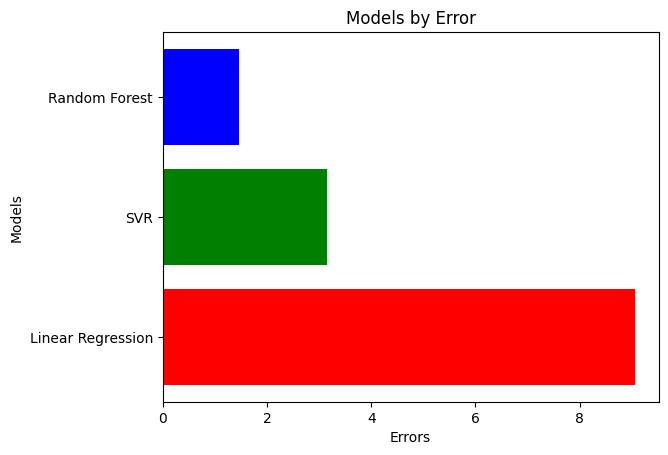

In [17]:
plt.barh(models,errors, color=colors)
plt.xlabel("Errors")
plt.ylabel("Models")
plt.title("Models by Error")
plt.show()

In [18]:
predict_frame = pd.DataFrame(pd.concat([pd.Series(y_test), pd.Series(rf_pred)], axis=1))

In [19]:
predict_frame = predict_frame.rename(columns={0:'Actual',
                      1:'Predicted'})
predict_frame

,Actual,Predicted
0,4.50,2.437400
1,3.57,5.998033
2,4.40,4.273833
3,0.90,0.786667
4,1.94,1.716933
5,0.88,1.050567
6,7.94,6.886667
7,1.10,1.069067
8,5.55,6.879267


<Axes: >

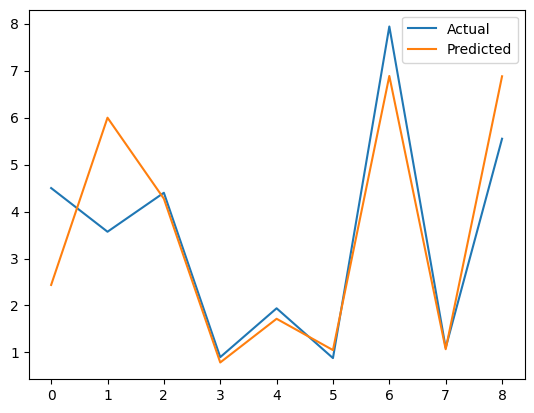

In [20]:
predict_frame.plot()